**Dechection, Modele Deep-Learning:**

### Le but ici est d'essayer de creer un modele CNN qui prend les images qui ont un seul dechet et de classifier le type de dechet y present. Apres ca, on ira vers un CNN plus global et qui touche aux images avec plusieurs dechets et leurs bounding boxes.
---



In [ ]:
# Monter le Google Drive (c'est ici le dataset se trouve)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Importations des bibliotheques necessaires

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter

In [ ]:
# Utiliser CUDA si possible pour accelerer la performance

if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Processeur disponible:", device, "device name:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Processeur disponible:", device)

Processeur disponible: cuda:0 device name: Tesla T4


In [ ]:
# Importation des donnees
# Analyse deja faite

archive_path = "/content/drive/MyDrive/archive"
csv_path = os.path.join(archive_path, "meta_df.csv")
data_path = os.path.join(archive_path, "data")
df = pd.read_csv(csv_path)

In [ ]:
# On va travailler sur les images qui ont un seul dechet seulement

img_nbr = df.groupby("img_id")["ann_id"].count()
img_ones = img_nbr[img_nbr == 1].index
dfs = df[df["img_id"].isin(img_ones)].reset_index(drop=True)
print(f"Il y a {len(dfs)} images avec un seul dechet.")
print(f"\nSupercategories:\n{dfs['supercategory'].value_counts()}") # On utiliser supercategory, pas category pour que ca n'aura pas d'imbalance

Il y a 610 images avec un seul dechet.

Supercategories:
supercategory
Plastic bag & wrapper    184
Bottle cap                57
Bottle                    54
Cup                       42
Other plastic             42
Can                       39
Carton                    33
Styrofoam piece           24
Paper                     20
Straw                     19
Plastic container         19
Unlabeled litter          16
Rope & strings            12
Aluminium foil            12
Lid                        7
Plastic utensils           6
Cigarette                  4
Pop tab                    3
Paper bag                  3
Scrap metal                3
Plastic glooves            3
Blister pack               2
Shoe                       2
Food waste                 1
Battery                    1
Broken glass               1
Squeezable tube            1
Name: count, dtype: int64


In [ ]:
# On fait un encoding pour les labels (supercategories)

label = "supercategory"
sc = sorted(dfs[label].unique())
c2i = {c: i for i, c in enumerate(sc)}
i2c = {i: c for c, i in c2i.items()}
nbr_classes = len(sc)
print(f"\nNombre de classes: {nbr_classes} -> {sc}")


Nombre de classes: 27 -> ['Aluminium foil', 'Battery', 'Blister pack', 'Bottle', 'Bottle cap', 'Broken glass', 'Can', 'Carton', 'Cigarette', 'Cup', 'Food waste', 'Lid', 'Other plastic', 'Paper', 'Paper bag', 'Plastic bag & wrapper', 'Plastic container', 'Plastic glooves', 'Plastic utensils', 'Pop tab', 'Rope & strings', 'Scrap metal', 'Shoe', 'Squeezable tube', 'Straw', 'Styrofoam piece', 'Unlabeled litter']


In [ ]:
# Creer la classe TACODataset

IMG_SIZE = 128  # Faut changer la taille de tous les images a 128x128

class TACODataset(Dataset):

    def __init__(self, dataframe, data_path, label, c2i, transform=None): # initialiseur
        self.df = dataframe.reset_index(drop=True)
        self.data_path = data_path
        self.label = label
        self.c2i = c2i
        self.transform = transform

    def __len__(self): # apporteur de taille
        return len(self.df)

    def __getitem__(self, idx): # apporteur d'item (image, supercategory)
        ligne = self.df.iloc[idx]
        img_path = os.path.join(self.data_path, ligne["img_file"])
        image = Image.open(img_path).convert("RGB")
        lb = self.c2i[ligne[self.label]]
        if self.transform:
            image = self.transform(image)
        return image, lb

In [ ]:
# Transformation d'images en tenseurs

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Preparation, repartition et loading des donnees

N = len(dfs)
N_train = int(N * 0.7)
N_valid = int(N * 0.15)
N_test  = N - N_train - N_valid

df_shuffled = dfs.sample(frac=1, random_state=42).reset_index(drop=True)
df_train = df_shuffled.iloc[:N_train]
df_valid = df_shuffled.iloc[N_train:N_train+N_valid]
df_test  = df_shuffled.iloc[N_train+N_valid:]

train_dataset = TACODataset(df_train, data_path, label, c2i, transform)
valid_dataset = TACODataset(df_valid, data_path, label, c2i, transform)
test_dataset  = TACODataset(df_test,  data_path, label, c2i, transform)

batch_size = 32
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
validloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Data:\nTrain: {N_train}- Valid: {N_valid}- Test: {N_test}")

Data:
Train: 427- Valid: 91- Test: 92


In [ ]:
# Classe de l'architecture du modele CNN

class CNN(nn.Module):

    def __init__(self, nbr_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        self.last_layer = nn.Linear(64 * 16 * 16, nbr_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.last_layer(x)

In [ ]:
# Ici, on cree les fonctions des boucles de l'entrainement, validation, et evaluation

def train_loop(dataloader, model, loss_fn, optimizer, device):
    nb_batches = len(dataloader)
    epoch_loss = 0
    pbar = tqdm(total=nb_batches, desc='Training', position=0)
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X.float())
        loss = loss_fn(pred, y)
        epoch_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pbar.set_postfix({'train_loss': loss.item()}, refresh=True)
        pbar.update(1)
    pbar.close()
    return epoch_loss / nb_batches

def valid_loop(dataloader, model, loss_fn, device):
    nb_batches = len(dataloader)
    valid_loss = 0
    pbar = tqdm(total=nb_batches, desc='Validation', position=0)
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X.float())
            valid_loss += loss_fn(pred, y).item()
            pbar.set_postfix({'valid_loss': valid_loss}, refresh=True)
            pbar.update(1)
    pbar.close()
    return valid_loss / nb_batches

def perf_loop(dataloader, model, device):
    Total = len(dataloader.dataset)
    Positifs = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X.float())
            prob_pred = nn.Softmax(dim=1)(pred)
            y_pred = torch.argmax(prob_pred, dim=1)
            Positifs += torch.sum(y_pred == y)
    return Positifs.cpu().numpy(), Total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

  5%|▌         | 1/20 [04:19<1:22:07, 259.32s/it]

Epoch 1: best validation loss: 2.7801


 10%|█         | 2/20 [05:23<43:23, 144.66s/it]  

Epoch 2: best validation loss: 2.7310


100%|██████████| 20/20 [24:54<00:00, 74.72s/it]

Training done!


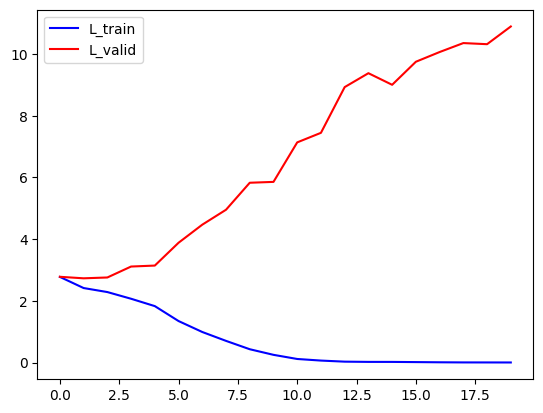

In [ ]:
# Entrainement du modele CNN

torch.manual_seed(42)

epochs = 20
learning_rate = 1e-3
OPTIM = "ADAM"
Model_name = "best_TACO_CNN.pt"

writer = SummaryWriter()

my_CNN = CNN(nbr_classes=nbr_classes).to(device)
my_loss = nn.CrossEntropyLoss()

if OPTIM == "ADAM":
    my_optimizer = torch.optim.Adam(my_CNN.parameters(), lr=learning_rate)
else:
    my_optimizer = torch.optim.SGD(my_CNN.parameters(), lr=learning_rate)

train_loss = []
valid_loss = []
best_valid_loss = float('inf')
best_iter = 0

for t in tqdm(range(epochs)):
    train_epoch_loss = train_loop(trainloader, my_CNN, my_loss, my_optimizer, device)
    train_loss.append(train_epoch_loss)
    writer.add_scalar('Loss/train', train_epoch_loss, t)

    valid_epoch_loss = valid_loop(validloader, my_CNN, my_loss, device)
    valid_loss.append(valid_epoch_loss)
    writer.add_scalar('Loss/valid', valid_epoch_loss, t)

    if valid_epoch_loss < best_valid_loss:
        best_valid_loss = valid_epoch_loss
        best_iter = t
        print(f"Epoch {t+1}: best validation loss: {best_valid_loss:.4f}")
        torch.save(my_CNN.state_dict(), Model_name)

print('Training done!')
plt.figure()
plt.plot(train_loss, "b", label="L_train")
plt.plot(valid_loss, "r", label="L_valid")
plt.legend()
plt.show()

In [ ]:
# Maintenant, on teste le modele

my_best_CNN = CNN(nbr_classes=nbr_classes).to(device)
my_best_CNN.load_state_dict(torch.load(Model_name))

Positifs, Total = perf_loop(testloader, my_best_CNN, device)
print(f"Test accuracy: {Positifs}/{Total} = {(Positifs/Total)*100:.2f}%")
print(f"Best epoch: {best_iter+1}")
print(f"Trainable parameters: {count_parameters(my_best_CNN)}")

writer.add_hparams({'lr': learning_rate, 'bsize': batch_size},
                   {'hparam/accuracy': Positifs/Total, 'hparam/loss': best_valid_loss})
writer.close()

Test accuracy: 30/92 = 32.61%
Best epoch: 2
Trainable parameters: 465979


Si on voit ces resultats, c'est pas bon. Le modele a eu du 'overfitting', car on a pas beaucoup de donnees apres avoir pris uniquement les images avec un seul dechet. Si on veut toujours travailler avec ces donnees avec leur count qui est pas vraiment suffisant, faut essayer avec un CNN qui est deja entraine, comme le RESNET. C'est possible d'avoir pas d'overfitting, mais c'est pas garanti.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]
  3%|▎         | 1/30 [01:05<31:53, 65.98s/it]

Epoch 1: best validation loss: 3.0392


  7%|▋         | 2/30 [02:07<29:38, 63.52s/it]

Epoch 2: best validation loss: 2.7266


 10%|█         | 3/30 [03:12<28:48, 64.02s/it]

Epoch 3: best validation loss: 2.6356


100%|██████████| 30/30 [32:12<00:00, 64.42s/it]

Training done.


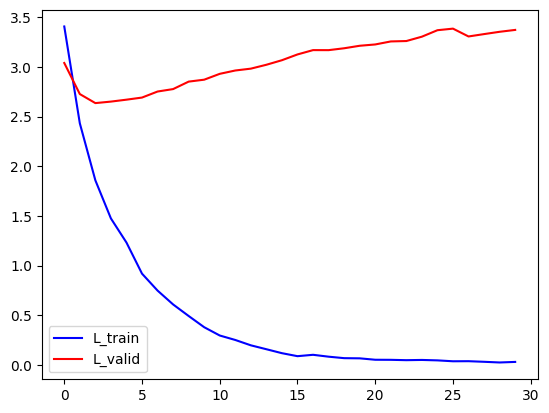

Test accuracy: 28/92 = 30.43%
Best epoch: 3
Trainable parameters: 11190363


In [ ]:
# Nouvel essai avec RESNET

import torchvision.models as models

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset2 = TACODataset(df_train, data_path, label, c2i, train_transform)
valid_dataset2 = TACODataset(df_valid, data_path, label, c2i, val_test_transform)
test_dataset2  = TACODataset(df_test,  data_path, label, c2i, val_test_transform)

trainloader2 = DataLoader(train_dataset2, batch_size=32, shuffle=True,  num_workers=2)
validloader2 = DataLoader(valid_dataset2, batch_size=32, shuffle=False, num_workers=2)
testloader2  = DataLoader(test_dataset2,  batch_size=32, shuffle=False, num_workers=2)

my_CNN2 = models.resnet18(weights="IMAGENET1K_V1")
my_CNN2.fc = nn.Linear(my_CNN2.fc.in_features, nbr_classes)
for param in my_CNN2.parameters():
    param.requires_grad = True
my_CNN2 = my_CNN2.to(device)

learning_rate2 = 1e-4
epochs2 = 30
Model_name2 = "best_TACO_CNN_v2.pt"

my_loss2 = nn.CrossEntropyLoss()
my_optimizer2 = torch.optim.Adam(my_CNN2.parameters(), lr=learning_rate2)

train_loss2 = []
valid_loss2 = []
best_valid_loss2 = float('inf')
best_iter2 = 0

for t in tqdm(range(epochs2)):
    train_epoch_loss = train_loop(trainloader2, my_CNN2, my_loss2, my_optimizer2, device)
    train_loss2.append(train_epoch_loss)

    valid_epoch_loss = valid_loop(validloader2, my_CNN2, my_loss2, device)
    valid_loss2.append(valid_epoch_loss)

    if valid_epoch_loss < best_valid_loss2:
        best_valid_loss2 = valid_epoch_loss
        best_iter2 = t
        print(f"Epoch {t+1}: best validation loss: {best_valid_loss2:.4f}")
        torch.save(my_CNN2.state_dict(), Model_name2)

print('Training done.')
plt.figure()
plt.plot(train_loss2, "b", label="L_train")
plt.plot(valid_loss2, "r", label="L_valid")
plt.legend()
plt.show()

my_best_CNN2 = models.resnet18(weights=None)
my_best_CNN2.fc = nn.Linear(my_best_CNN2.fc.in_features, nbr_classes)
my_best_CNN2.load_state_dict(torch.load(Model_name2))
my_best_CNN2 = my_best_CNN2.to(device)

Positifs2, Total2 = perf_loop(testloader2, my_best_CNN2, device)
print(f"Test accuracy: {Positifs2}/{Total2} = {(Positifs2/Total2)*100:.2f}%")
print(f"Best epoch: {best_iter2+1}")
print(f"Trainable parameters: {count_parameters(my_best_CNN2)}")

Meme avec RESNET, ce type de boulot n'est pas fonctionnel. Ca revient au nombre des data points qu'on a qui est pas suffisant. Faut pas donc limiter notre CNN primaire avec les elements d'un seul type de dechet par image.